Hotel Fake Review Detection

1. Load cleaned dataset


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud 
from collections import Counter

# Load cleaned dataset
hotel_df = pd.read_csv('../data/processed/hotel_final_clean.csv')
hotel_df.head()

,text,label
0,stayed one night getaway family thursday tripl...,0
1,triple rate upgrade view room less 200 also in...,0
2,come little late im finally catching review pa...,0
3,omni chicago really delivers front spaciousnes...,0
4,asked high floor away elevator got room pleasa...,0


2. Label Distribution

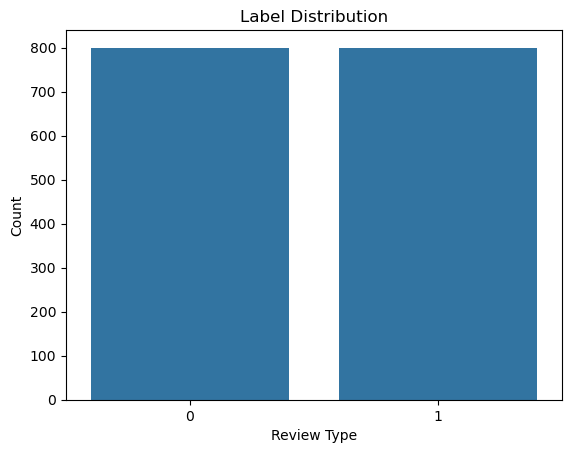

In [4]:
plt.Figure(figsize=(6, 4))
sns.countplot(data=hotel_df, x='label')
plt.title('Label Distribution')
plt.xlabel('Review Type')
plt.ylabel('Count')
plt.show()

3. Review Length Analysis

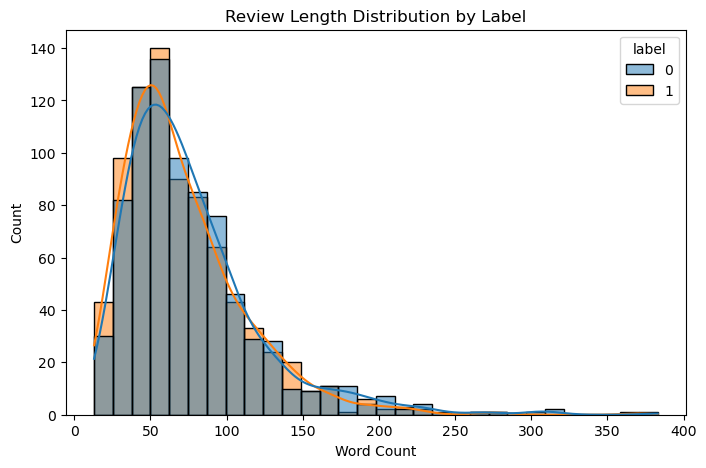

In [8]:
# Calculate review length
hotel_df['review_length'] = hotel_df['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 5))
sns.histplot(data=hotel_df, x='review_length', hue='label', bins=30, kde=True)
plt.title('Review Length Distribution by Label')
plt.xlabel('Word Count')
plt.show()

4. WorldCloud Visualization

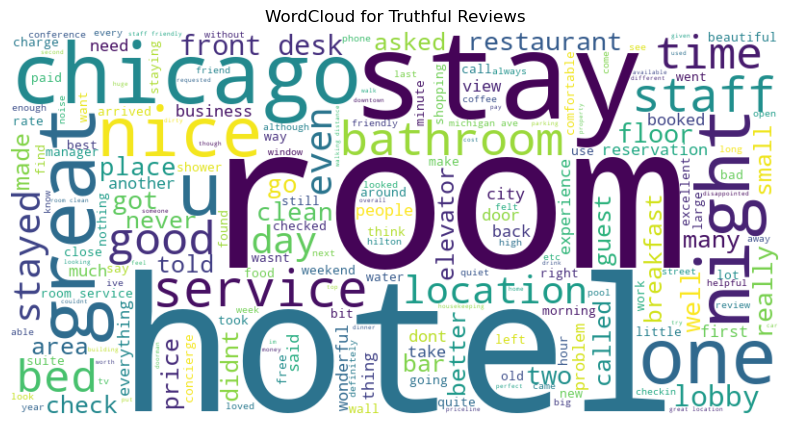

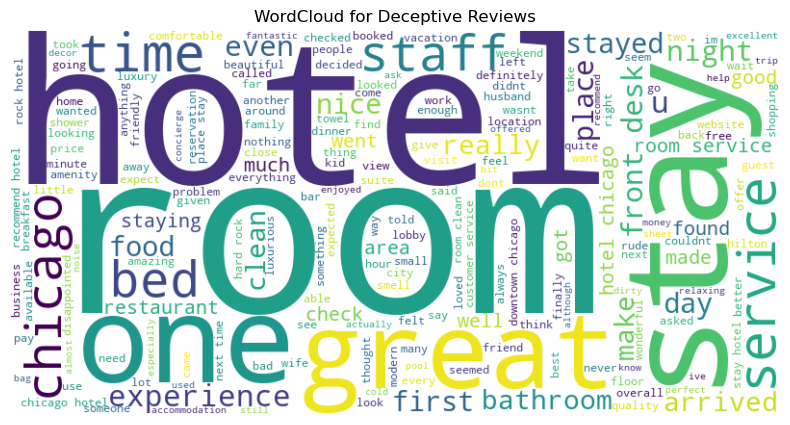

In [10]:
# Map labels 0/1 to text labels for visualization
hotel_df['label_text'] = hotel_df['label'].map({0: 'truthful', 1: 'deceptive'})

# Function to generate word cloud
def genetate_wordcloud(texts, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(''.join(texts))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

genetate_wordcloud(hotel_df[hotel_df['label_text'] == 'truthful']['text'], 'WordCloud for Truthful Reviews')
genetate_wordcloud(hotel_df[hotel_df['label_text'] == 'deceptive']['text'], 'WordCloud for Deceptive Reviews')

5. Common Word Analysis

In [11]:
def get_top_words(texts, n=20):
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

truthful_top_words = get_top_words(hotel_df[hotel_df['label_text'] == 'truthful']['text'])
deceptive_top_words = get_top_words(hotel_df[hotel_df['label_text'] == 'deceptive']['text'])

print("Top 10 Truthful Words:", truthful_top_words[:10])
print("Top 10 Deceptive Words:", deceptive_top_words[:10])

Top 10 Truthful Words: [('room', 1715), ('hotel', 1646), ('stay', 610), ('great', 541), ('chicago', 485), ('would', 443), ('staff', 438), ('night', 434), ('service', 394), ('bed', 372)]
Top 10 Deceptive Words: [('hotel', 1982), ('room', 1736), ('chicago', 1034), ('stay', 708), ('would', 473), ('service', 461), ('staff', 400), ('one', 360), ('time', 342), ('like', 329)]


6. Sample Review Inspection

In [14]:
print("Sample Truthful Review:\n", hotel_df[hotel_df['label_text'] == 'truthful'].sample(3, random_state=1)['text'].values)
print("\nSample Deceptive Review:\n", hotel_df[hotel_df['label_text'] == 'deceptive'].sample(3, random_state=2)['text'].values)

Sample Truthful Review:
 ['arrived omni 2nd september 6 day stay took ill left plane travelling manchester saw room anticipated couldnt go 4 day room spacious clean bed extremely comfortable bathroom large clean could ask coffee juice left outside door every morning time requested managed go 5th floor see sun terrace outside gym sun terrace city hotel great idea terrace bit grim sunbeds concrete floor also noise air conditioning unit could bit cheering saw chicago pleasing something everyone would go back omni yes would'
 'upon first entering hotel greeted friendly helpful bellman ever encountered 2 week stay told u nice day left welcomed u back upon return breakfast served server delightful bellman enjoyable stay'
 'excellent location block michigan ave two block water tower place john hancock tower beautiful hotel felt luxurious highclass moderate priced hotel staff excellent friendly accommodating']

Sample Deceptive Review:
 ['husband stayed hyatt regency attending family wedding c

7. Observation
- The dataset remains balanced in labels.
- Truthful reviews tend to be slightly longer than deceptive ones.
- Word clouds show that deceptive reviews favor emotionally charged language, while truthful ones mention specific nouns.
- Sample deceptive reviews often sound generic or exaggerated.

These findings suggest that review length, vocabulary patterns, and sentiment strength may be useful features for classification